In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
X_train = np.linspace(-1,1,20)

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [4]:
X_test = np.linspace(-1,1,20)

In [5]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

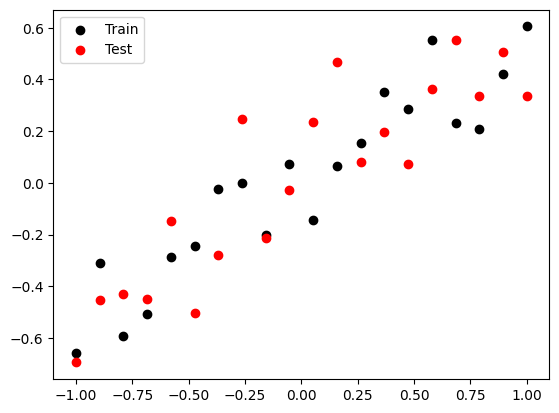

In [8]:
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.legend()
plt.show()

### Regression Model

In [10]:
model1 = Sequential()

model1.add(Dense(128,input_dim=1,activation="relu"))
model1.add(Dense(128,activation="relu"))
model1.add(Dense(1,activation='linear'))

adam = Adam(learning_rate=0.01)
model1.compile(loss='mse', optimizer=adam,metrics=['mse'])
history = model1.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500


d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1083 - mse: 0.1083 - val_loss: 0.0280 - val_mse: 0.0280
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0183 - mse: 0.0183 - val_loss: 0.0494 - val_mse: 0.0494
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0400 - mse: 0.0400 - val_loss: 0.0354 - val_mse: 0.0354
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0245 - mse: 0.0245 - val_loss: 0.0299 - val_mse: 0.0299
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0170 - mse: 0.0170 - val_loss: 0.0389 - val_mse: 0.0389
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0245 - mse: 0.0245 - val_loss: 0.0404 - val_mse: 0.0404
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0254 - mse: 0.0254 - val_loss: 0.0346 - val_mse: 0.0346
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0196 - mse: 0.0196 - val_loss: 0.0308 - val_mse: 0.0308
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0159 - mse: 0.0159

In [16]:

# evaluate the model
_, train_mse = model1.evaluate(X_train, y_train, verbose=1)
_, test_mse = model1.evaluate(X_test, y_test, verbose=1)
print(f'Train: {train_mse}, Test: {test_mse}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0046 - mse: 0.0046
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0449 - mse: 0.0449
Train: 0.004616762511432171, Test: 0.04491342231631279


In [19]:
y_pred_1 = model1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


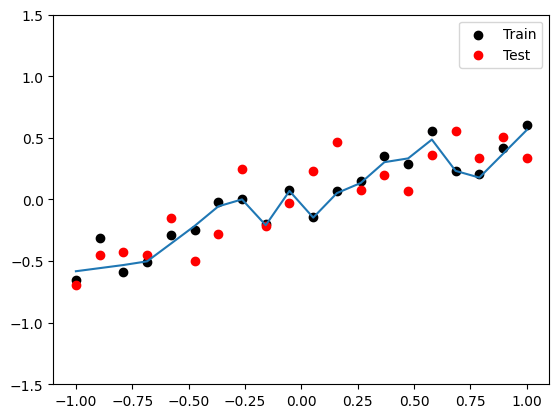

In [20]:
plt.figure()
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

### Dropout Model

In [33]:
model2 = Sequential()

model2.add(Dense(128,input_dim=1,activation="relu"))
model2.add(Dropout(0.2))
model2.add(Dense(128,activation="relu"))
model2.add(Dropout(0.2))
model2.add(Dense(1,activation="linear"))

adam = Adam(learning_rate=0.01)
model2.compile(loss='mse',optimizer=adam,metrics=['mse'])

dropout_history = model2.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=0)

In [34]:
# evaluate the model
_, train_mse = model2.evaluate(X_train, y_train, verbose=1)
_, test_mse = model2.evaluate(X_test, y_test, verbose=1)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0111 - mse: 0.0111
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0401 - mse: 0.0401
Train: 0.011056254617869854, Test: 0.04007077217102051


In [35]:
y_pred_2 = model2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


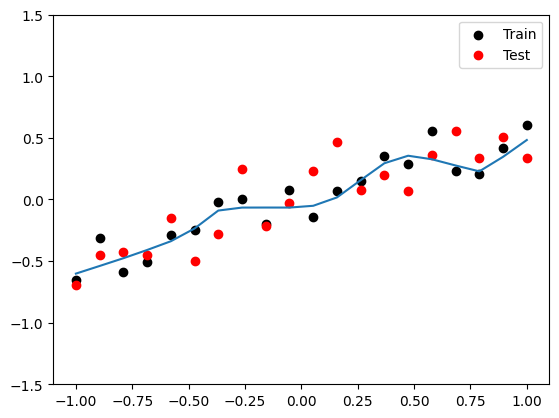

In [36]:
plt.figure()
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

In [37]:
model2 = Sequential()

model2.add(Dense(128,input_dim=1,activation="relu"))
model2.add(Dropout(0.5))
model2.add(Dense(128,activation="relu"))
model2.add(Dropout(0.5))
model2.add(Dense(1,activation="linear"))

adam = Adam(learning_rate=0.01)
model2.compile(loss='mse',optimizer=adam,metrics=['mse'])

dropout_history = model2.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=0)

In [39]:
# evaluate the model
_, train_mse = model2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.017551161348819733, Test: 0.040889300405979156


In [40]:
y_pred_2 = model2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


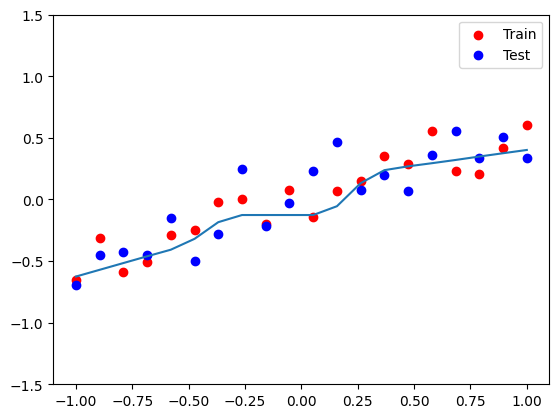

In [41]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()